In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from keras.datasets import mnist, fashion_mnist

# Load Data


In [ ]:
# Function to normalize a dataset
def normalize_data(matrix):
    scaler = MinMaxScaler()
    return scaler.fit_transform(matrix)

# Load MNIST dataset
def load_mnist():
    print("Loading MNIST dataset...")
    (X_train, _), (_, _) = mnist.load_data()
    X_train = X_train.reshape(X_train.shape[0], -1)  # Flatten images
    print(f"MNIST dataset loaded with shape: {X_train.shape}")
    return normalize_data(X_train)

# Load Fashion-MNIST dataset
def load_fashion_mnist():
    print("Loading Fashion-MNIST dataset...")
    (X_train, _), (_, _) = fashion_mnist.load_data()
    X_train = X_train.reshape(X_train.shape[0], -1)  # Flatten images
    print(f"Fashion-MNIST dataset loaded with shape: {X_train.shape}")
    return normalize_data(X_train)

# Load Covertype dataset
def load_covertype():
    print("Loading Covertype dataset...")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"
    columns = [f"Feature_{i+1}" for i in range(54)] + ["Cover_Type"]
    covertype_df = pd.read_csv(url, header=None, names=columns)
    X = covertype_df.iloc[:, :-1].to_numpy()
    print(f"Covertype dataset loaded with shape: {X.shape}")
    return normalize_data(X)

# Load and preprocess the MovieLens dataset
def load_movielens():
    print("Loading MovieLens dataset...")

    # URL to the MovieLens dataset (replace with the appropriate dataset URL)
    url = 'https://files.grouplens.org/datasets/movielens/ml-latest.zip'

    # Download and extract the ZIP file (You can use `zipfile` to extract it)
    import zipfile
    import io
    import requests

    # Download the ZIP file
    response = requests.get(url)

    # Extract the ZIP file content
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        # Read the ratings.csv file
        with z.open('ml-latest/ratings.csv') as f:
            ratings_df = pd.read_csv(f)

    # Group by userId and movieId to create a user-item matrix
    user_movie_matrix = ratings_df.pivot(index='userId', columns='movieId', values='rating')

    # Replace NaN values with the mean rating of the respective user
    user_movie_matrix_filled = user_movie_matrix.apply(lambda row: row.fillna(row.mean()), axis=1)

    # Convert the matrix to a NumPy array
    matrix = user_movie_matrix_filled.to_numpy()

    # Optionally normalize the data
    normalized_matrix = normalize_data(matrix)

    print("MovieLens dataset loaded and preprocessed.")
    print(f"Shape of the preprocessed matrix: {normalized_matrix.shape}")

    return normalized_matrix

In [ ]:
# Load datasets
datasets = {}
datasets['MNIST'] = load_mnist()
datasets['Fashion-MNIST'] = load_fashion_mnist()
datasets['Covertype'] = load_covertype()
# datasets['MovieLens'] = load_movielens()

# Print summaries of all datasets
print("\nSummary of loaded datasets:")
for name, data in datasets.items():
    print(f"{name}: Shape = {data.shape}")

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST dataset loaded with shape: (60000, 784)
Loading Fashion-MNIST dataset...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fashion-MNIST dataset loaded with shape: (60000, 784)
Loading Covertype dataset...
Covertype dataset loaded with shape: (581012, 54)

Summary of loaded datasets:
MNIST: Shape = (60000, 784)
Fashion-MNIST: Shape = (60000, 784)
Covertype: Shape = (581012, 54)


In [ ]:
for name, data in datasets.items():
    print(f"Summary Statistics for {name}:")
    print(f" - Shape: {data.shape}")
    print(f" - Mean: {np.mean(data):.4f}")
    print(f" - Std Dev: {np.std(data):.4f}")
    print(f" - Min: {np.min(data):.4f}")
    print(f" - Max: {np.max(data):.4f}")
    print(f" - Number of NaNs: {np.isnan(data).sum()}")

Summary Statistics for MNIST:
 - Shape: (60000, 784)
 - Mean: 0.1307
 - Std Dev: 0.3081
 - Min: 0.0000
 - Max: 1.0000
 - Number of NaNs: 0
Summary Statistics for Fashion-MNIST:
 - Shape: (60000, 784)
 - Mean: 0.2861
 - Std Dev: 0.3530
 - Min: 0.0000
 - Max: 1.0000
 - Number of NaNs: 0
Summary Statistics for Covertype:
 - Shape: (581012, 54)
 - Mean: 0.1214
 - Std Dev: 0.2758
 - Min: 0.0000
 - Max: 1.0000
 - Number of NaNs: 0


# Algorithms

## Empirical Mean

In [ ]:
def emp_mean_accuracy(train_ds, sample_size, reps=50):
  errors = []
  x_min = np.mean(train_ds, axis=0)
  OPT = np.sum(np.linalg.norm(train_ds - x_min, axis=1)**2)
  n, d = train_ds.shape
  for _ in range(reps):
    sample_indices = np.random.choice(n, sample_size, replace=False)
    sample = train_ds[sample_indices, :]
    emp_mean = np.mean(sample, axis=0)
    obj_value = np.sum(np.linalg.norm(train_ds - emp_mean, axis=1)**2)
    error = obj_value/OPT
    errors.append(error)
  return errors

## Common subroutines: Compute empirical means and winner

In [ ]:
def compute_empirical_means(train_ds, sample_size):
    """
    Compute empirical means of random subsets of the dataset and count good means.

    Parameters:
    - train_ds: The training dataset (numpy array).
    - epsilon: The error tolerance.
    - delta: The failure probability.

    Returns:
    - empirical_means: A numpy array of empirical means computed from subsets.
    """
    n, d = train_ds.shape

    num_batches = min(n, max(3, int(np.log(sample_size))))
    batch_size = sample_size//num_batches

    empirical_means = np.zeros((num_batches, d))

    for i in range(num_batches):
        # Sample a subset of the dataset
        sample_indices = np.random.choice(n, batch_size, replace=False)
        sample = train_ds[sample_indices, :]

        # Compute the empirical mean for the subset
        emp_mean = np.mean(sample, axis=0)
        empirical_means[i, :] = emp_mean

    # Compute a random initial guess
    sample_indices = np.random.choice(n, batch_size, replace=False)
    sample = train_ds[sample_indices, :]
    emp_mean = np.mean(sample, axis=0)
    rand_initial_guess = emp_mean

    return empirical_means, rand_initial_guess

In [ ]:
def compute_winner(P):
    """
    Computes the winner point in the set P based on the algorithm.

    Parameters:
    - P: numpy array of shape (n, d), where n is the number of points and d is the dimension.

    Returns:
    - winner_index: int, the index of the point in P that minimizes D_j.
    """
    m, d = P.shape
    distances = np.zeros(m)  # Array to store D_j values for each point

    for j, p_j in enumerate(P):
        # Compute distances from p_j to all other points
        all_distances = np.linalg.norm(P - p_j, axis=1)

        # Find the threshold distance for the 7/10 closest point
        k = int(0.7 * m)
        threshold_distance = np.partition(all_distances, k)[k]

        # Compute D_j as the sum of distances for points within the threshold
        distances[j] = np.sum(all_distances[all_distances <= threshold_distance])

    # Find the point that minimizes D_j
    winner_index = np.argmin(distances)
    winner_point = P[winner_index]
    return winner_point

## Fast Gradient Descent

In [ ]:
def fast_gd(P, initial_guess):
    """
    Fast Gradient Descent (FastGD) for geometric median computation.

    Parameters:
    - P: numpy array of shape (n, d), where n is the number of points, and d is the dimension.
    - sample_size: int, number of samples given to the algorithm.
    - initial_guess: numpy array of shape (d,), initial guess for the geometric median.

    Returns:
    - c_T: numpy array of shape (d,), the computed geometric median after T iterations.
    """
    m, d = P.shape

    # Initialize the geometric median with the mean of the points or the provided initial guess
    c_prev = initial_guess

    num_batches = max(3, int(np.log(m)))
    T = 50 * num_batches

    for _ in range(T):
        for p in P:
          if np.isnan(np.linalg.norm(p - c_prev)):
            break
        # Compute the gradient ∇(c_prev)
        gradient = np.sum([(p - c_prev) / np.linalg.norm(p - c_prev) for p in P], axis=0)

        # Direction: ∇(c_prev) - c_prev
        direction = gradient - c_prev
        direction_norm = np.linalg.norm(direction)
        if direction_norm == 0:
            break  # Stop if direction becomes 0 to avoid division by zero
        direction /= direction_norm

        # Project all points onto the line defined by direction
        projections = np.dot(P - c_prev, direction)

        # Compute the 1-dimensional median of the projections
        median_projection = np.median(projections)

        # Update c_prev: Move along the line to the median projection
        c_next = c_prev + median_projection * direction

        # Update the current guess
        c_prev = c_next

    return c_prev

def fastgd_accs_runtimes(sample_size, train_ds, OPT, init, reps=50):
    n, d = train_ds.shape
    accuracies = []
    runtimes = []
    for _ in range(reps):
      start_time = time.time()
      P, rand_initial_guess = compute_empirical_means(train_ds, sample_size)
      if init == 'rand':
        initial_guess = rand_initial_guess # randomly seeded initial guess
      else:
        initial_guess = np.median(P, axis=0) # seeded initial guess is coordinate-wise median
      c = fast_gd(P, initial_guess)
      loss = np.sum(np.linalg.norm(train_ds - c, axis=1)**2)
      if np.isnan(loss):
          break
      runtimes.append(time.time() - start_time)
      accuracies.append(loss/OPT)
    return accuracies, runtimes

def coordmed_accs_runtimes(sample_size, train_ds, OPT, init, reps=50):
    n, d = train_ds.shape
    accuracies = []
    runtimes = []
    for _ in range(reps):
      start_time = time.time()
      P, rand_initial_guess = compute_empirical_means(train_ds, sample_size)
      c = np.median(P, axis=0)
      loss = np.sum(np.linalg.norm(train_ds - c, axis=1)**2)
      if np.isnan(loss):
          break
      runtimes.append(time.time() - start_time)
      accuracies.append(loss/OPT)
    return accuracies, runtimes

## MinSumSelect

In [ ]:
def minsumselect(P, i=1):
    """
    Implements the MinSumSelect algorithm with recursion depth i, default i=1.

    Parameters:
    - P: numpy array of shape (n, d), the set of points.
    - i: int, recursion depth.

    Returns:
    - winner_point: numpy array of shape (d,), the point that minimizes the sum of distances.
    """
    if i == 0 or len(P) == 1:
        return compute_winner(P)

    # Number of clusters: sqrt(|P|)
    m = len(P)
    cluster_size = int(np.sqrt(m))
    clusters = [P[k:k + cluster_size] for k in range(0, m, cluster_size)]

    # Initialize the winner set W
    W = []

    # Process each cluster recursively
    for cluster in clusters:
        winner = minsumselect(cluster, i - 1)
        W.append(winner)

    # Compute the winner of W
    W = np.array(W)
    return compute_winner(W)

def minsum_accs_runtimes(sample_size, train_ds, OPT, reps=50):
    n, d = train_ds.shape
    accuracies = []
    runtimes = []
    for _ in range(reps):
      start_time = time.time()
      P, _ = compute_empirical_means(train_ds, sample_size)
      c = minsumselect(P)
      loss = np.sum(np.linalg.norm(train_ds - c, axis=1)**2)
      if np.isnan(loss):
          break
      runtimes.append(time.time() - start_time)
      accuracies.append(loss/OPT)
    return accuracies, runtimes

## Ring Sampling (Cohen-Addad, Saulpic, Schwiegelshohn, NeurIPS 2022)

In [ ]:
def css(P, sample_size):
    n, d = P.shape
    points = P

    num_batches = min(n, max(3, int(np.log(sample_size))))
    batch_size = sample_size//num_batches

    # Compute initial solution
    sample_indices = np.random.choice(n, num_batches, replace=False)
    sample = P[sample_indices, :]
    winner = compute_winner(sample)

    # Discard far points
    all_distances = np.linalg.norm(P - winner, axis=1)
    k = int(0.95 * n)
    threshold_distance = np.partition(all_distances, k)[k]
    indices = P[all_distances <= threshold_distance]

    return np.mean(indices, axis=0)

def css_accs_runtimes(sample_size, train_ds, OPT, reps=50):
    n, d = train_ds.shape
    accuracies = []
    runtimes = []
    for _ in range(reps):
      start_time = time.time()
      # P, _ = compute_empirical_means(train_ds, sample_size)
      c = css(train_ds, sample_size)
      loss = np.sum(np.linalg.norm(train_ds - c, axis=1)**2)
      if np.isnan(loss):
          break
      runtimes.append(time.time() - start_time)
      accuracies.append(loss/OPT)
    return accuracies, runtimes

## Coresets for Multiple $\ell_p$ Regression (Woodruff and Yasuda, ICML 2024)

In [ ]:
def wy(P, sample_size):
    n, d = P.shape
    points = P

    num_batches = min(n, max(3, int(np.log(sample_size))))
    batch_size = sample_size//num_batches

    # Compute initial solution
    sample_indices = np.random.choice(n, num_batches, replace=False)
    sample = P[sample_indices, :]
    winner = compute_winner(sample)

    # Subtract winner from each point
    for j, p_j in enumerate(P):
      points[j] = P[j] - winner

    empirical_means = np.zeros((num_batches, d))
    distances = np.zeros(num_batches)

    result = 0

    for i in range(num_batches):
        # Sample a subset of the dataset
        sample_indices = np.random.choice(n, batch_size, replace=False)
        sample = train_ds[sample_indices, :]

        # Compute the empirical mean for the subset
        emp_mean = np.mean(sample, axis=0)
        empirical_means[i, :] = emp_mean

        # Compute cost for each empirical mean
        distances[i] = np.sum(np.square(np.linalg.norm(sample - emp_mean, axis=1)))

        # Maintain minimum cost
        if (distances[i] < distances[result]):
            result = i

    return empirical_means[result]

def wy_accs_runtimes(sample_size, train_ds, OPT, reps=50):
    n, d = train_ds.shape
    accuracies = []
    runtimes = []
    for _ in range(reps):
      start_time = time.time()
      # P, _ = compute_empirical_means(train_ds, sample_size)
      c = wy(train_ds, sample_size)
      loss = np.sum(np.linalg.norm(train_ds - c, axis=1)**2)
      if np.isnan(loss):
          break
      runtimes.append(time.time() - start_time)
      accuracies.append(loss/OPT)
    return accuracies, runtimes

# Run simulations on all algorithms

## Real datasets

Running simulations for MNIST...


Running for various sample sizes: 100%|██████████| 12/12 [25:07<00:00, 125.62s/it]


Accuracy Results for MNIST:


,Empirical Mean Mean,Empirical Mean Std Dev,Fast GD Mean,Fast GD Std Dev,Coordinate-wise Median Mean,Coordinate-wise Median Std Dev,MinSumSelect Mean,MinSumSelect Std Dev,CSS Mean,CSS Std Dev,WY Mean,WY Std Dev
Sample Size,,,,,,,,,,,,
10,1.098528,0.028635,1.155126,0.034458,1.175892,0.037900,1.302344,0.063439,1.001193,0.000261,1.350220,0.109802
15,1.068796,0.023853,1.091481,0.021414,1.098388,0.016651,1.175579,0.041341,1.001193,0.000290,1.183068,0.040979
20,1.050844,0.011704,1.071097,0.016169,1.078405,0.015386,1.150386,0.033795,1.001149,0.000299,1.166793,0.036811
25,1.042582,0.012022,1.058092,0.013787,1.058672,0.011956,1.108955,0.023705,1.001170,0.000305,1.120348,0.024574
30,1.035064,0.009891,1.042930,0.008184,1.045296,0.009135,1.091521,0.016238,1.001194,0.000290,1.097966,0.022739
100,1.009560,0.002129,1.011862,0.002859,1.012232,0.002303,1.041629,0.011196,1.001229,0.000242,1.042088,0.011341
200,1.004758,0.000965,1.007189,0.001490,1.007697,0.001541,1.022338,0.003845,1.001251,0.000228,1.025489,0.005615
500,1.001954,0.000498,1.002661,0.000648,1.002704,0.000572,1.010681,0.002279,1.001248,0.000221,1.012654,0.002601
1000,1.000921,0.000239,1.001301,0.000301,1.001286,0.000261,1.005201,0.001092,1.001310,0.000216,1.006786,0.001536


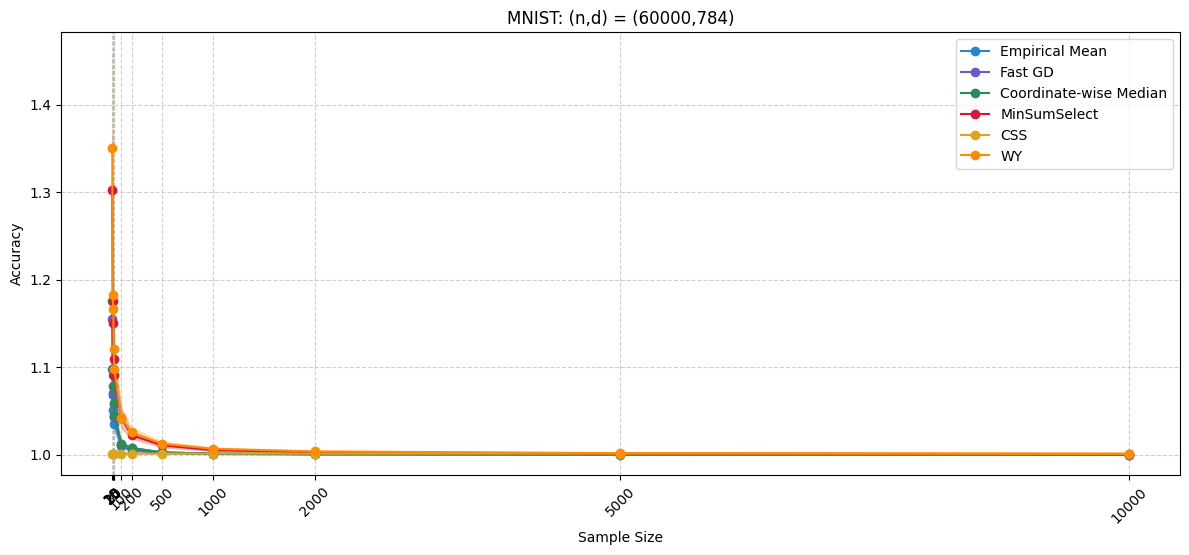


Runtime Results for MNIST:


,Fast GD Mean,Fast GD Std Dev,Coordinate-wise Median Mean,Coordinate-wise Median Std Dev,MinSumSelect Mean,MinSumSelect Std Dev,CSS Mean,CSS Std Dev,WY Mean,WY Std Dev
Sample Size,,,,,,,,,,
10,0.331120,0.032523,0.303807,0.021514,0.305031,0.022829,0.752144,0.047994,0.496704,0.101033
15,0.328824,0.029853,0.305248,0.023860,0.304551,0.019328,0.750669,0.052915,0.468601,0.059539
20,0.321185,0.022370,0.313300,0.026494,0.304787,0.021680,0.753925,0.049201,0.469229,0.060214
25,0.320447,0.024325,0.305469,0.018924,0.312867,0.026952,0.758650,0.052323,0.454810,0.045884
30,0.324699,0.023393,0.306246,0.021164,0.307380,0.021195,0.754389,0.050649,0.468448,0.061920
100,0.332200,0.029719,0.305576,0.022594,0.304266,0.021536,0.753291,0.047923,0.471533,0.064869
200,0.339868,0.032710,0.307593,0.021998,0.306124,0.020822,0.753950,0.052971,0.472828,0.057820
500,0.341225,0.032963,0.311128,0.020642,0.309915,0.021704,0.757828,0.053416,0.476949,0.061728
1000,0.340164,0.028454,0.313098,0.025072,0.308668,0.021177,0.757372,0.050639,0.478237,0.062858


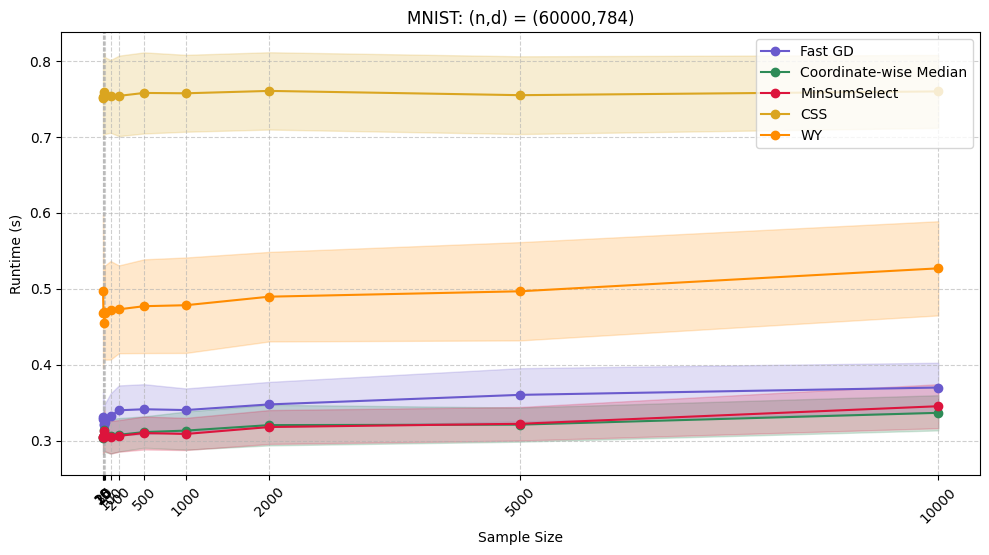

Running simulations for Fashion-MNIST...


Running for various sample sizes: 100%|██████████| 12/12 [25:34<00:00, 127.91s/it]


Accuracy Results for Fashion-MNIST:


,Empirical Mean Mean,Empirical Mean Std Dev,Fast GD Mean,Fast GD Std Dev,Coordinate-wise Median Mean,Coordinate-wise Median Std Dev,MinSumSelect Mean,MinSumSelect Std Dev,CSS Mean,CSS Std Dev,WY Mean,WY Std Dev
Sample Size,,,,,,,,,,,,
10,1.093860,0.038502,1.168206,0.072249,1.158600,0.063016,1.262712,0.084508,1.002085,0.000535,1.410225,0.186138
15,1.059763,0.025435,1.072933,0.022016,1.093171,0.038484,1.152191,0.044532,1.001925,0.000602,1.223075,0.112463
20,1.047630,0.021119,1.071868,0.030577,1.078761,0.036302,1.133899,0.057035,1.002081,0.000560,1.188065,0.091863
25,1.037592,0.016507,1.055227,0.023691,1.052861,0.018430,1.099373,0.034629,1.002027,0.000576,1.154098,0.084204
30,1.033326,0.017267,1.047521,0.021427,1.047434,0.025508,1.081450,0.027367,1.001970,0.000608,1.117492,0.058351
100,1.008636,0.003856,1.010393,0.003980,1.012369,0.005928,1.039607,0.016125,1.002181,0.000501,1.042559,0.023257
200,1.004966,0.002634,1.007437,0.003222,1.006969,0.002530,1.019005,0.007038,1.002268,0.000513,1.027004,0.013877
500,1.001731,0.000808,1.002640,0.001184,1.002666,0.000941,1.008731,0.003001,1.002119,0.000607,1.014062,0.006417
1000,1.000995,0.000514,1.001402,0.000511,1.001307,0.000560,1.004691,0.001845,1.002137,0.000514,1.006923,0.003087


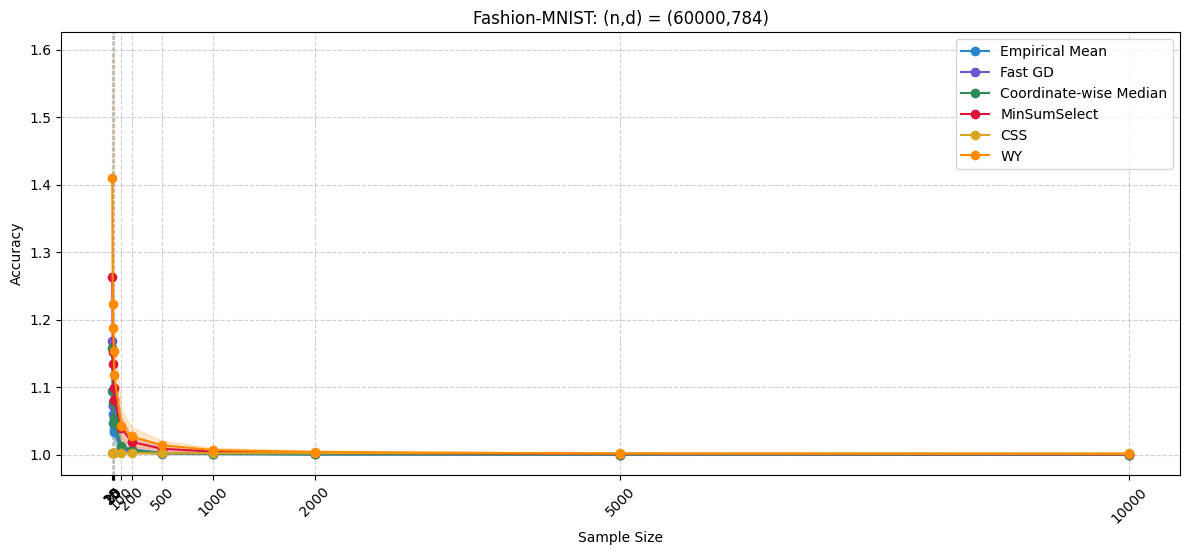


Runtime Results for Fashion-MNIST:


,Fast GD Mean,Fast GD Std Dev,Coordinate-wise Median Mean,Coordinate-wise Median Std Dev,MinSumSelect Mean,MinSumSelect Std Dev,CSS Mean,CSS Std Dev,WY Mean,WY Std Dev
Sample Size,,,,,,,,,,
10,0.321448,0.023380,0.312952,0.026512,0.305658,0.023760,0.756740,0.050820,0.468331,0.057475
15,0.321034,0.025382,0.306104,0.022794,0.311527,0.026256,0.756574,0.050337,0.462625,0.050791
20,0.323577,0.024019,0.306152,0.021286,0.311567,0.023307,0.762976,0.052009,0.466120,0.054934
25,0.324687,0.024464,0.307812,0.021872,0.305509,0.022212,0.759280,0.053497,0.468656,0.058419
30,0.337589,0.031150,0.314179,0.024323,0.314793,0.026307,0.768198,0.049296,0.475917,0.059172
100,0.339825,0.030971,0.313864,0.021833,0.314656,0.021192,0.770439,0.050707,0.479234,0.061036
200,0.343429,0.034035,0.314607,0.022087,0.315744,0.022180,0.776043,0.055347,0.484026,0.058062
500,0.344963,0.029201,0.317037,0.024013,0.321864,0.024046,0.777818,0.052920,0.482666,0.054302
1000,0.342908,0.026467,0.321385,0.019771,0.330206,0.030062,0.782083,0.053366,0.490609,0.061393


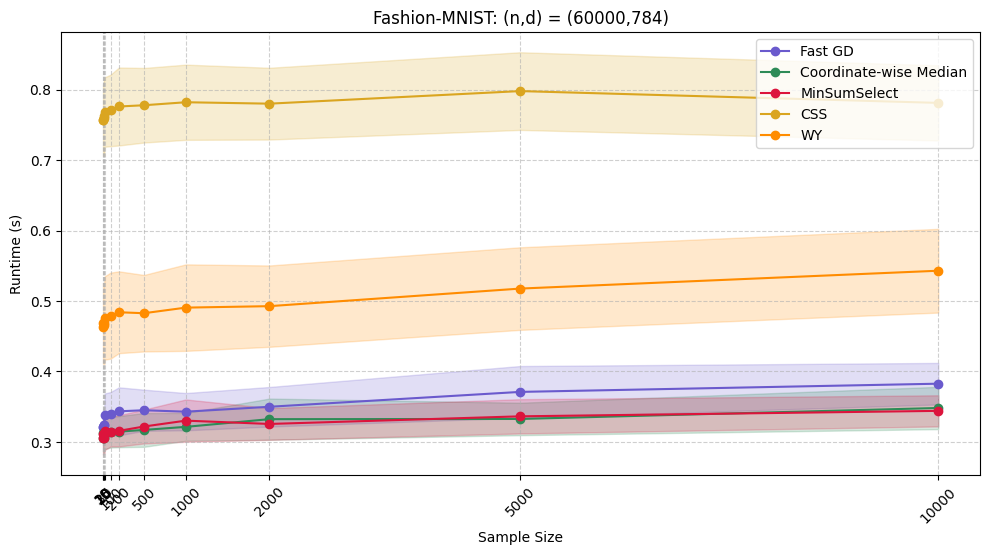

Running simulations for Covertype...


Running for various sample sizes: 100%|██████████| 12/12 [31:13<00:00, 156.11s/it]


Accuracy Results for Covertype:


,Empirical Mean Mean,Empirical Mean Std Dev,Fast GD Mean,Fast GD Std Dev,Coordinate-wise Median Mean,Coordinate-wise Median Std Dev,MinSumSelect Mean,MinSumSelect Std Dev,CSS Mean,CSS Std Dev,WY Mean,WY Std Dev
Sample Size,,,,,,,,,,,,
10,1.108636,0.042217,1.119267,0.043644,1.157506,0.075030,1.272808,0.090469,1.001215,0.000288,1.415904,0.144695
15,1.066584,0.022068,1.074480,0.030927,1.105394,0.055913,1.158538,0.054230,1.001191,0.000254,1.236552,0.086584
20,1.049573,0.022078,1.057441,0.021246,1.089662,0.040425,1.140825,0.050728,1.001133,0.000253,1.195730,0.089347
25,1.036512,0.018078,1.053686,0.029706,1.065375,0.025584,1.094168,0.026889,1.001123,0.000234,1.145422,0.061505
30,1.036691,0.019793,1.037201,0.018052,1.055018,0.023190,1.072072,0.022397,1.001183,0.000312,1.115283,0.048031
100,1.009314,0.003971,1.011745,0.005836,1.013494,0.005759,1.039665,0.019413,1.001185,0.000293,1.048990,0.025024
200,1.004612,0.002427,1.005690,0.002576,1.007420,0.003117,1.018879,0.006906,1.001240,0.000263,1.025955,0.011816
500,1.001898,0.000764,1.002419,0.001025,1.003009,0.001046,1.009276,0.004027,1.001093,0.000286,1.013968,0.007303
1000,1.000900,0.000446,1.001310,0.000855,1.001306,0.000607,1.004540,0.001544,1.001180,0.000275,1.006637,0.003337


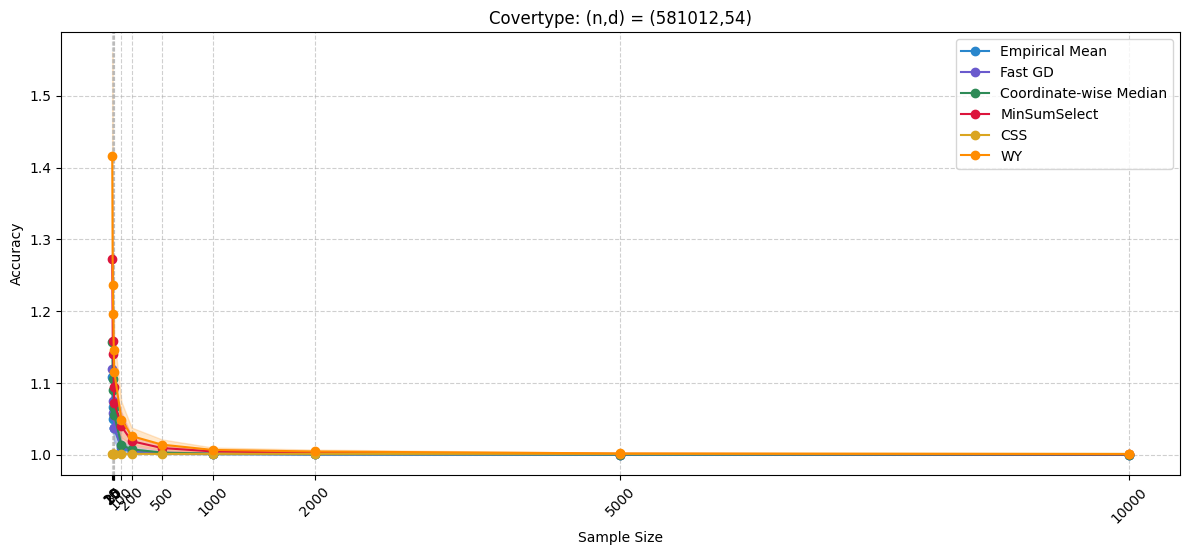


Runtime Results for Covertype:


,Fast GD Mean,Fast GD Std Dev,Coordinate-wise Median Mean,Coordinate-wise Median Std Dev,MinSumSelect Mean,MinSumSelect Std Dev,CSS Mean,CSS Std Dev,WY Mean,WY Std Dev
Sample Size,,,,,,,,,,
10,0.314651,0.046157,0.282404,0.031080,0.288587,0.034383,0.613419,0.046794,1.245482,0.258989
15,0.306077,0.036779,0.298309,0.040512,0.292406,0.035746,0.613963,0.047924,1.257660,0.253154
20,0.301770,0.031940,0.294962,0.037142,0.296320,0.037489,0.615424,0.055335,1.249950,0.250474
25,0.303237,0.031811,0.287583,0.031934,0.294039,0.032757,0.620881,0.058844,1.242681,0.247920
30,0.300530,0.035609,0.285710,0.030116,0.286007,0.031816,0.606604,0.052007,1.236148,0.254896
100,0.331999,0.048713,0.303365,0.034886,0.306587,0.032373,0.605893,0.055305,1.264738,0.243610
200,0.342839,0.044078,0.314886,0.036705,0.317887,0.037454,0.606486,0.053486,1.264084,0.247365
500,0.351567,0.040367,0.338988,0.041819,0.341309,0.047003,0.596981,0.045806,1.279043,0.251941
1000,0.370986,0.058853,0.338823,0.043989,0.336769,0.041462,0.610185,0.053088,1.282619,0.269218


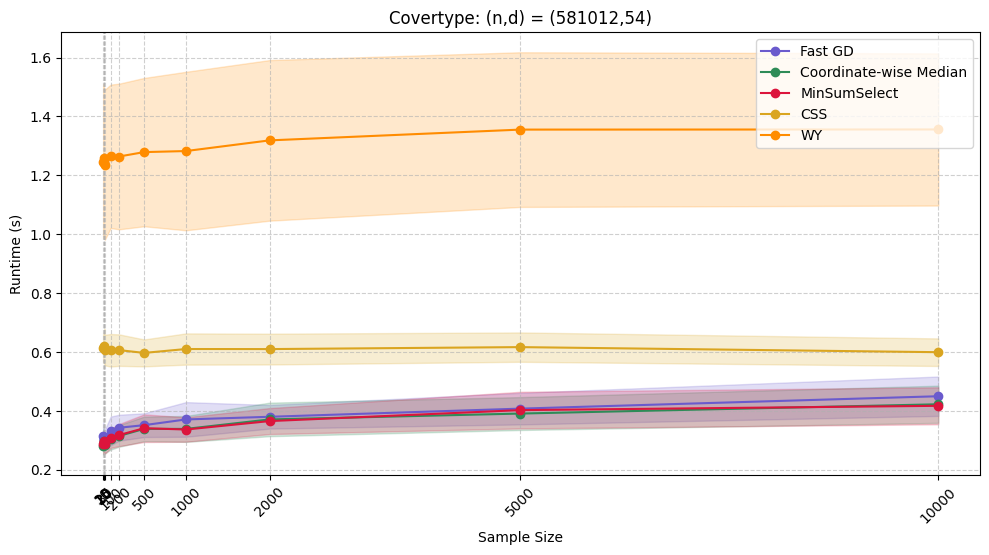

In [ ]:
for dataset_name, train_ds in datasets.items():
    # if dataset_name != 'MNIST':
    #   break
    print(f"Running simulations for {dataset_name}...")
    n, d = train_ds.shape
    sample_sizes = [10, 15, 20, 25, 30, 100, 200, 500, 1000, 2000, 5000, 10000]

    x_min = np.mean(train_ds, axis=0)
    OPT = np.sum(np.linalg.norm(train_ds - x_min, axis=1)**2)

    empmean_accuracies = []
    fastgd_accuracies = []
    fastgd_runtimes = []
    coordmed_accuracies = []
    coordmed_runtimes = []
    minsum_accuracies = []
    minsum_runtimes = []
    # fastgd_rand_accuracies = []
    # fastgd_rand_runtimes = []
    wy_accuracies = []
    wy_runtimes = []
    css_accuracies = []
    css_runtimes = []

    for sample_size in tqdm(sample_sizes, desc="Running for various sample sizes"):
      empmean_accuracies_sample = emp_mean_accuracy(train_ds, sample_size)
      empmean_accuracies.append(empmean_accuracies_sample)
      fastgd_accuracies_sample, fastgd_runtimes_sample = fastgd_accs_runtimes(sample_size, train_ds, OPT, init='median')
      fastgd_accuracies.append(fastgd_accuracies_sample)
      fastgd_runtimes.append(fastgd_runtimes_sample)
      coordmed_accuracies_sample, coordmed_runtimes_sample = coordmed_accs_runtimes(sample_size, train_ds, OPT, init='median')
      coordmed_accuracies.append(coordmed_accuracies_sample)
      coordmed_runtimes.append(coordmed_runtimes_sample)
      # fastgd_rand_accuracies_sample, fastgd_rand_runtimes_sample = fastgd_accs_runtimes(sample_size, train_ds, OPT, init='rand')
      # fastgd_rand_accuracies.append(fastgd_rand_accuracies_sample)
      # fastgd_rand_runtimes.append(fastgd_rand_runtimes_sample)
      minsum_accuracies_sample, minsum_runtimes_sample = minsum_accs_runtimes(sample_size, train_ds, OPT)
      minsum_accuracies.append(minsum_accuracies_sample)
      minsum_runtimes.append(minsum_runtimes_sample)
      wy_accuracies_sample, wy_runtimes_sample = wy_accs_runtimes(sample_size, train_ds, OPT)
      wy_accuracies.append(wy_accuracies_sample)
      wy_runtimes.append(wy_runtimes_sample)
      css_accuracies_sample, css_runtimes_sample = css_accs_runtimes(sample_size, train_ds, OPT)
      css_accuracies.append(css_accuracies_sample)
      css_runtimes.append(css_runtimes_sample)


    # Various algorithms
    experiments_accuracies = [empmean_accuracies, fastgd_accuracies, coordmed_accuracies, minsum_accuracies, css_accuracies, wy_accuracies]
    experiments_runtimes = [fastgd_runtimes, coordmed_runtimes, minsum_runtimes, css_runtimes, wy_runtimes]

    # Colors and labels for each set (in accuracies)
    colors_acc = ['#2986CC', '#6A5ACD', '#2E8B57', '#DC143C', '#DAA520', '#FF8C00']
    labels_acc = ['Empirical Mean', 'Fast GD', 'Coordinate-wise Median', 'MinSumSelect', 'CSS', 'WY']

    # Create and display table for accuracies
    accuracy_data = {}
    for idx, experiment_set in enumerate(experiments_accuracies):
        avgs = [np.mean(results) for results in experiment_set]
        std_devs = [np.std(results) for results in experiment_set]
        accuracy_data[labels_acc[idx] + ' Mean'] = avgs
        accuracy_data[labels_acc[idx] + ' Std Dev'] = std_devs

    accuracy_df = pd.DataFrame(accuracy_data, index=sample_sizes)
    accuracy_df.index.name = 'Sample Size'
    print(f"\nAccuracy Results for {dataset_name}:")
    display(accuracy_df)

    # Plot each set of experiments for accuracies
    plt.figure(figsize=(12, 6))

    for idx, experiment_set in enumerate(experiments_accuracies):
        # Compute means and standard deviations for the current set
        avgs = [np.mean(results) for results in experiment_set]
        std_devs = [np.std(results) for results in experiment_set]

        # Plot the mean curve
        plt.plot(sample_sizes, avgs, marker='o', label=labels_acc[idx], color=colors_acc[idx])

        # Add shaded area for standard deviation
        plt.fill_between(
            sample_sizes,
            [m - s for m, s in zip(avgs, std_devs)],  # Lower bound
            [m + s for m, s in zip(avgs, std_devs)],  # Upper bound
            color=colors_acc[idx],
            alpha=0.2
        )

    # Customize the plot
    # plt.xscale('symlog', linthresh=30)
    plt.xlabel('Sample Size')
    plt.ylabel('Accuracy')
    plt.title(dataset_name + ": (n,d) = (" + str(n) + "," + str(d) + ")")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right')
    # Improve tick visibility
    plt.xticks(sample_sizes, sample_sizes, rotation=45)
    plt.tick_params(axis='x', labelsize=10)
    # Ensure everything fits well
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)  # Extra space for rotated labels
    plt.show()

    # Colors and labels for each set (in runtimes)
    colors_run = ['#6A5ACD', '#2E8B57', '#DC143C', '#DAA520', '#FF8C00']
    labels_run = ['Fast GD', 'Coordinate-wise Median', 'MinSumSelect', 'CSS', 'WY']

    # Create and display table for runtimes
    runtime_data = {}
    for idx, experiment_set in enumerate(experiments_runtimes):
        avgs = [np.mean(results) for results in experiment_set]
        std_devs = [np.std(results) for results in experiment_set]
        runtime_data[labels_run[idx] + ' Mean'] = avgs
        runtime_data[labels_run[idx] + ' Std Dev'] = std_devs

    runtime_df = pd.DataFrame(runtime_data, index=sample_sizes)
    runtime_df.index.name = 'Sample Size'
    print(f"\nRuntime Results for {dataset_name}:")
    display(runtime_df)

    # Plot each set of experiments for runtimes
    plt.figure(figsize=(10, 6))

    for idx, experiment_set in enumerate(experiments_runtimes):
        # Compute means and standard deviations for the current set
        avgs = [np.mean(results) for results in experiment_set]
        std_devs = [np.std(results) for results in experiment_set]

        # Plot the mean curve
        plt.plot(sample_sizes, avgs, marker='o', label=labels_run[idx], color=colors_run[idx])

        # Add shaded area for standard deviation
        plt.fill_between(
            sample_sizes,
            [m - s for m, s in zip(avgs, std_devs)],  # Lower bound
            [m + s for m, s in zip(avgs, std_devs)],  # Upper bound
            color=colors_run[idx],
            alpha=0.2
        )

    # Customize the plot
    # plt.xscale('symlog', linthresh=30)
    plt.xlabel('Sample Size')
    plt.ylabel('Runtime (s)')
    plt.title(dataset_name + ": (n,d) = (" + str(n) + "," + str(d) + ")")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right')
    # Improve tick visibility
    plt.xticks(sample_sizes, sample_sizes, rotation=45)
    plt.tick_params(axis='x', labelsize=10)
    # Ensure everything fits well
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)  # Extra space for rotated labels
    plt.show()

## Synthetic Dataset

In [ ]:
# Function to generate a dataset of random points
def generate_random_dataset(num_points, dimension=200):
    print(f"Generating a random dataset with {num_points} points and dimension {dimension}...")
    return np.random.rand(num_points, dimension)

### Fixed dimension (d=200) and varying sample size m


In [ ]:
# Define the sample sizes, which will also be the number of points in the random dataset
sample_sizes = [10, 15, 20, 25, 30, 100, 200, 500, 1000, 2000, 5000, int(1e4), int(1e5), 5*int(1e5)]
# sample_sizes = [5*int(1e5)]

dim = 200

# Lists to store results for plotting
all_empmean_accuracies = []
all_empmean_stddevs = []
all_fastgd_accuracies = []
all_fastgd_stddevs = []
all_fastgd_runtimes = []
all_fastgd_runtime_stddevs = []
all_coordmed_accuracies = []
all_coordmed_stddevs = []
all_coordmed_runtimes = []
all_coordmed_runtime_stddevs = []
all_minsum_accuracies = []
all_minsum_stddevs = []
all_minsum_runtimes = []
all_minsum_runtime_stddevs = []
all_wy_accuracies = []
all_wy_stddevs = []
all_wy_runtimes = []
all_wy_runtime_stddevs = []
all_css_accuracies = []
all_css_stddevs = []
all_css_runtimes = []
all_css_runtime_stddevs = []


# Generate the random dataset for the current sample size
# This loop will run the simulations for each sample size, creating a new random dataset each time
for sample_size in tqdm(sample_sizes, desc="Running simulations"):
    dataset_name = f"Random_{sample_size}"
    train_ds = generate_random_dataset(sample_size, dimension=dim)
    n, d = train_ds.shape

    x_min = np.mean(train_ds, axis=0)
    OPT = np.sum(np.linalg.norm(train_ds - x_min, axis=1)**2)

    # Since the dataset size is now the sample size, we run each algorithm once
    empmean_accuracies_sample = emp_mean_accuracy(train_ds, sample_size)
    all_empmean_accuracies.append(np.mean(empmean_accuracies_sample)) # Store mean of accuracies
    all_empmean_stddevs.append(np.std(empmean_accuracies_sample)) # Store std dev of accuracies

    fastgd_accuracies_sample, fastgd_runtimes_sample = fastgd_accs_runtimes(sample_size, train_ds, OPT, init='median')
    all_fastgd_accuracies.append(np.mean(fastgd_accuracies_sample)) # Store mean of accuracies
    all_fastgd_stddevs.append(np.std(fastgd_accuracies_sample)) # Store std dev of accuracies
    all_fastgd_runtimes.append(np.mean(fastgd_runtimes_sample)) # Store mean of runtimes
    all_fastgd_runtime_stddevs.append(np.std(fastgd_runtimes_sample)) # Store std dev of runtimes

    coordmed_accuracies_sample, coordmed_runtimes_sample = coordmed_accs_runtimes(sample_size, train_ds, OPT, init='median')
    all_coordmed_accuracies.append(np.mean(coordmed_accuracies_sample)) # Store mean of accuracies
    all_coordmed_stddevs.append(np.std(coordmed_accuracies_sample)) # Store std dev of accuracies
    all_coordmed_runtimes.append(np.mean(coordmed_runtimes_sample)) # Store mean of runtimes
    all_coordmed_runtime_stddevs.append(np.std(coordmed_runtimes_sample)) # Store std dev of runtimes

    minsum_accuracies_sample, minsum_runtimes_sample = minsum_accs_runtimes(sample_size, train_ds, OPT)
    all_minsum_accuracies.append(np.mean(minsum_accuracies_sample)) # Store mean of accuracies
    all_minsum_stddevs.append(np.std(minsum_accuracies_sample)) # Store std dev of accuracies
    all_minsum_runtimes.append(np.mean(minsum_runtimes_sample)) # Store mean of runtimes
    all_minsum_runtime_stddevs.append(np.std(minsum_runtimes_sample)) # Store std dev of runtimes

    wy_accuracies_sample, wy_runtimes_sample = wy_accs_runtimes(sample_size, train_ds, OPT)
    all_wy_accuracies.append(np.mean(wy_accuracies_sample)) # Store mean of accuracies
    all_wy_stddevs.append(np.std(wy_accuracies_sample)) # Store std dev of accuracies
    all_wy_runtimes.append(np.mean(wy_runtimes_sample)) # Store mean of runtimes
    all_wy_runtime_stddevs.append(np.std(wy_runtimes_sample)) # Store std dev of runtimes

    css_accuracies_sample, css_runtimes_sample = css_accs_runtimes(sample_size, train_ds, OPT)
    all_css_accuracies.append(np.mean(css_accuracies_sample)) # Store mean of accuracies
    all_css_stddevs.append(np.std(css_accuracies_sample)) # Store std dev of accuracies
    all_css_runtimes.append(np.mean(css_runtimes_sample)) # Store mean of runtimes
    all_css_runtime_stddevs.append(np.std(css_runtimes_sample)) # Store std dev of runtimes


# Various algorithms accuracies and std devs
experiments_accuracies_rand = [all_empmean_accuracies, all_fastgd_accuracies, all_coordmed_accuracies, all_minsum_accuracies, all_css_accuracies, all_wy_accuracies]
experiments_accuracies_stddevs_rand = [all_empmean_stddevs, all_fastgd_stddevs, all_coordmed_stddevs, all_minsum_stddevs, all_css_stddevs, all_wy_stddevs]
# Various algorithms runtimes and std devs
experiments_runtimes_rand = [all_fastgd_runtimes, all_coordmed_runtimes, all_minsum_runtimes, all_css_runtimes, all_wy_runtimes]
experiments_runtimes_stddevs_rand = [all_fastgd_runtime_stddevs, all_coordmed_runtime_stddevs, all_minsum_runtime_stddevs, all_css_runtime_stddevs, all_wy_runtime_stddevs]

# Colors and labels for each set (in accuracies)
colors_acc = ['#2986CC', '#6A5ACD', '#2E8B57', '#DC143C', '#DAA520', '#FF8C00']
labels_acc = ['Empirical Mean', 'Fast GD', 'Coordinate-wise Median', 'MinSumSelect', 'CSS', 'WY']

# Create and display table for accuracies
accuracy_data = {}
for idx, experiment_set in enumerate(experiments_accuracies_rand):
    accuracy_data[labels_acc[idx] + ' Mean'] = experiment_set
    accuracy_data[labels_acc[idx] + ' Std Dev'] = experiments_accuracies_stddevs_rand[idx]

accuracy_df = pd.DataFrame(accuracy_data, index=sample_sizes)
accuracy_df.index.name = 'Sample Size'
print(f"\nAccuracy Results for Random Dataset (Fixed Dimension d={dim}):")
display(accuracy_df)

# Plot each set of experiments for accuracies
plt.figure(figsize=(12, 6))

for idx, experiment_set in enumerate(experiments_accuracies_rand):
    # Plot the mean curve
    plt.plot(sample_sizes, experiment_set, marker='o', label=labels_acc[idx], color=colors_acc[idx])

    # Add shaded area for standard deviation
    plt.fill_between(
        sample_sizes,
        [m - s for m, s in zip(experiment_set, experiments_accuracies_stddevs_rand[idx])],  # Lower bound
        [m + s for m, s in zip(experiment_set, experiments_accuracies_stddevs_rand[idx])],  # Upper bound
        color=colors_acc[idx],
        alpha=0.2
    )


# Customize the plot
# plt.xscale('symlog', linthresh=30)
plt.xlabel('Sample Size')
plt.ylabel('Accuracy')
plt.title("Random Dataset Accuracy: (n,d) = (Sample Size, 200)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
# Improve tick visibility
plt.xticks(sample_sizes, sample_sizes, rotation=45)
plt.tick_params(axis='x', labelsize=10)
# Ensure everything fits well
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Extra space for rotated labels
plt.show()

# Colors and labels for each set (in runtimes)
colors_run = ['#6A5ACD', '#2E8B57', '#DC143C', '#DAA520', '#FF8C00']
labels_run = ['Fast GD', 'Coordinate-wise Median', 'MinSumSelect', 'CSS', 'WY']

# Create and display table for runtimes
runtime_data = {}
for idx, experiment_set in enumerate(experiments_runtimes_rand):
    runtime_data[labels_run[idx] + ' Mean'] = experiment_set
    runtime_data[labels_run[idx] + ' Std Dev'] = experiments_runtimes_stddevs_rand[idx]

runtime_df = pd.DataFrame(runtime_data, index=sample_sizes)
runtime_df.index.name = 'Sample Size'
print(f"\nRuntime Results for Random Dataset (Fixed Dimension d={dim}):")
display(runtime_df)

# Plot each set of experiments for runtimes
plt.figure(figsize=(12, 6))

for idx, experiment_set in enumerate(experiments_runtimes_rand):
    # Plot the mean curve
    plt.plot(sample_sizes, experiment_set, marker='o', label=labels_run[idx], color=colors_run[idx])

    # Add shaded area for standard deviation
    plt.fill_between(
        sample_sizes,
        [m - s for m, s in zip(experiment_set, experiments_runtimes_stddevs_rand[idx])],  # Lower bound
        [m + s for m, s in zip(experiment_set, experiments_runtimes_stddevs_rand[idx])],  # Upper bound
        color=colors_run[idx],
        alpha=0.2
    )


# Customize the plot
# plt.xscale('symlog', linthresh=30)
# plt.xscale('log')
plt.xlabel('Sample Size')
plt.ylabel('Runtime (s)')
plt.title("Random Dataset Runtime: (n,d) = (Sample Size, 200)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
# Improve tick visibility
plt.xticks(sample_sizes, sample_sizes, rotation=45)
plt.tick_params(axis='x', labelsize=10)
# Ensure everything fits well
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Extra space for rotated labels
plt.show()

In [ ]:
# Colors and labels for each set (in accuracies)
colors_acc = ['#2986CC', '#6A5ACD', '#2E8B57', '#DC143C', '#DAA520', '#FF8C00']
labels_acc = ['Empirical Mean', 'Fast GD', 'Coordinate-wise Median', 'MinSumSelect', 'CSS', 'WY']

# Plot each set of experiments for accuracies
plt.figure(figsize=(12, 6))

for idx, experiment_set in enumerate(experiments_accuracies_rand):
    # Plot the mean curve
    plt.plot(sample_sizes, experiment_set, marker='o', label=labels_acc[idx], color=colors_acc[idx])

    # Add shaded area for standard deviation
    plt.fill_between(
        sample_sizes,
        [m - s for m, s in zip(experiment_set, experiments_accuracies_stddevs_rand[idx])],  # Lower bound
        [m + s for m, s in zip(experiment_set, experiments_accuracies_stddevs_rand[idx])],  # Upper bound
        color=colors_acc[idx],
        alpha=0.2
    )


# Customize the plot
# plt.xscale('symlog', linthresh=30)
plt.xlabel('Sample Size')
plt.ylabel('Accuracy')
plt.title("Random Dataset Accuracy: (n,d) = (Sample Size, 200)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
# Improve tick visibility
plt.xticks(sample_sizes, sample_sizes, rotation=45)
plt.tick_params(axis='x', labelsize=10)
# Ensure everything fits well
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Extra space for rotated labels
plt.show()

# Colors and labels for each set (in runtimes)
colors_run = ['#6A5ACD', '#2E8B57', '#DC143C', '#DAA520', '#FF8C00']
labels_run = ['Fast GD', 'Coordinate-wise Median', 'MinSumSelect', 'CSS', 'WY']

# Plot each set of experiments for runtimes
plt.figure(figsize=(12, 6))

for idx, experiment_set in enumerate(experiments_runtimes_rand):
    # Plot the mean curve
    plt.plot(sample_sizes, experiment_set, marker='o', label=labels_run[idx], color=colors_run[idx])

    # Add shaded area for standard deviation
    plt.fill_between(
        sample_sizes,
        [m - s for m, s in zip(experiment_set, experiments_runtimes_stddevs_rand[idx])],  # Lower bound
        [m + s for m, s in zip(experiment_set, experiments_runtimes_stddevs_rand[idx])],  # Upper bound
        color=colors_run[idx],
        alpha=0.2
    )


# Customize the plot
# plt.xscale('symlog', linthresh=30)
# plt.xscale('log')
plt.xlabel('Sample Size')
plt.ylabel('Runtime (s)')
plt.title("Random Dataset Runtime: (n,d) = (Sample Size, 200)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
# Improve tick visibility
plt.xticks(sample_sizes, sample_sizes, rotation=45)
plt.tick_params(axis='x', labelsize=10)
# Ensure everything fits well
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Extra space for rotated labels
plt.show()

In [ ]:
# Colors and labels for each set (in runtimes)
colors_run = ['#6A5ACD', '#2E8B57', '#DC143C', '#DAA520', '#FF8C00']
labels_run = ['Fast GD', 'Coordinate-wise Median', 'MinSumSelect', 'CSS', 'WY']

# Define threshold for grouping
threshold = 10000
group_label = '10-10000'

# Build new x positions: small samples all mapped to x=0 (as a group), others kept separate
x_positions = []
x_labels = []
unique_positions = []

for size in sample_sizes:
    if size <= threshold:
        if group_label not in x_labels:
            x_labels.append(group_label)
            unique_positions.append(0)
        x_positions.append(0)
    else:
        x_labels.append(str(size))
        unique_positions.append(size)
        x_positions.append(size)

unique_positions = sorted(set(x_positions))
x_labels = sorted(set(x_labels), key=lambda x: float(x.split('–')[-1]) if '–' in x else int(x))

# Plot
plt.figure(figsize=(12, 6))

for idx, experiment_set in enumerate(experiments_runtimes_rand):
    # Collapse values at same position (x=0 for small sizes): take mean across those points
    y_vals = []
    for pos in unique_positions:
        if pos == 0:
            y_group = [val for i, val in enumerate(experiment_set) if sample_sizes[i] <= threshold]
            mean_val = np.mean(y_group)
            std_val = np.std(y_group)
        else:
            i = sample_sizes.index(pos)
            mean_val = experiment_set[i]
            std_val = experiments_runtimes_stddevs_rand[idx][i]
        y_vals.append((mean_val, std_val))

    y_means = [m for m, _ in y_vals]
    y_stds = [s for _, s in y_vals]

    # Plot mean and fill between std
    plt.plot(unique_positions, y_means, marker='o', label=labels_run[idx], color=colors_run[idx])
    plt.fill_between(
        unique_positions,
        [m - s for m, s in zip(y_means, y_stds)],
        [m + s for m, s in zip(y_means, y_stds)],
        color=colors_run[idx],
        alpha=0.2
    )

# Customize
plt.xlabel('Sample Size')
plt.ylabel('Runtime (s)')
plt.title("Runtime vs Sample Size (Grouped for Samples ≤ 10,000)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

### Fixed sample size (m=1000, m=10000) and varying dimension d


In [ ]:
# Define fixed sample sizes and varying dimensions
fixed_sample_sizes = [1000, 10000]
dimensions = [10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

for sample_size in fixed_sample_sizes:
    # Lists to store results for plotting for the current fixed sample size
    all_empmean_accuracies = []
    all_empmean_stddevs = []
    all_fastgd_accuracies = []
    all_fastgd_stddevs = []
    all_fastgd_runtimes = []
    all_fastgd_runtime_stddevs = []
    all_coordmed_accuracies = []
    all_coordmed_stddevs = []
    all_coordmed_runtimes = []
    all_coordmed_runtime_stddevs = []
    all_minsum_accuracies = []
    all_minsum_stddevs = []
    all_minsum_runtimes = []
    all_minsum_runtime_stddevs = []
    all_wy_accuracies = []
    all_wy_stddevs = []
    all_wy_runtimes = []
    all_wy_runtime_stddevs = []
    all_css_accuracies = []
    all_css_stddevs = []
    all_css_runtimes = []
    all_css_runtime_stddevs = []

    # This loop will run the simulations for each dimension, with a fixed sample size
    for dimension in dimensions:
        train_ds = generate_random_dataset(sample_size, dimension)
        n, d = train_ds.shape

        x_min = np.mean(train_ds, axis=0)
        OPT = np.sum(np.linalg.norm(train_ds - x_min, axis=1)**2)

        # Since the dataset size is now the sample size, we run each algorithm once
        empmean_accuracies_sample = emp_mean_accuracy(train_ds, sample_size)
        all_empmean_accuracies.append(np.mean(empmean_accuracies_sample)) # Store mean of accuracies
        all_empmean_stddevs.append(np.std(empmean_accuracies_sample)) # Store std dev of accuracies

        fastgd_accuracies_sample, fastgd_runtimes_sample = fastgd_accs_runtimes(sample_size, train_ds, OPT, init='median')
        all_fastgd_accuracies.append(np.mean(fastgd_accuracies_sample)) # Store mean of accuracies
        all_fastgd_stddevs.append(np.std(fastgd_accuracies_sample)) # Store std dev of accuracies
        all_fastgd_runtimes.append(np.mean(fastgd_runtimes_sample)) # Store mean of runtimes
        all_fastgd_runtime_stddevs.append(np.std(fastgd_runtimes_sample)) # Store std dev of runtimes

        coordmed_accuracies_sample, coordmed_runtimes_sample = coordmed_accs_runtimes(sample_size, train_ds, OPT, init='median')
        all_coordmed_accuracies.append(np.mean(coordmed_accuracies_sample)) # Store mean of accuracies
        all_coordmed_stddevs.append(np.std(coordmed_accuracies_sample)) # Store std dev of accuracies
        all_coordmed_runtimes.append(np.mean(coordmed_runtimes_sample)) # Store mean of runtimes
        all_coordmed_runtime_stddevs.append(np.std(coordmed_runtimes_sample)) # Store std dev of runtimes

        minsum_accuracies_sample, minsum_runtimes_sample = minsum_accs_runtimes(sample_size, train_ds, OPT)
        all_minsum_accuracies.append(np.mean(minsum_accuracies_sample)) # Store mean of accuracies
        all_minsum_stddevs.append(np.std(minsum_accuracies_sample)) # Store std dev of accuracies
        all_minsum_runtimes.append(np.mean(minsum_runtimes_sample)) # Store mean of runtimes
        all_minsum_runtime_stddevs.append(np.std(minsum_runtimes_sample)) # Store std dev of runtimes

        wy_accuracies_sample, wy_runtimes_sample = wy_accs_runtimes(sample_size, train_ds, OPT)
        all_wy_accuracies.append(np.mean(wy_accuracies_sample)) # Store mean of accuracies
        all_wy_stddevs.append(np.std(wy_accuracies_sample)) # Store std dev of accuracies
        all_wy_runtimes.append(np.mean(wy_runtimes_sample)) # Store mean of runtimes
        all_wy_runtime_stddevs.append(np.std(wy_runtimes_sample)) # Store std dev of runtimes

        css_accuracies_sample, css_runtimes_sample = css_accs_runtimes(sample_size, train_ds, OPT)
        all_css_accuracies.append(np.mean(css_accuracies_sample)) # Store mean of accuracies
        all_css_stddevs.append(np.std(css_accuracies_sample)) # Store std dev of accuracies
        all_css_runtimes.append(np.mean(css_runtimes_sample)) # Store mean of runtimes
        all_css_runtime_stddevs.append(np.std(css_runtimes_sample)) # Store std dev of runtimes


    # Various algorithms accuracies and std devs
    experiments_accuracies = [all_empmean_accuracies, all_fastgd_accuracies, all_coordmed_accuracies, all_minsum_accuracies, all_css_accuracies, all_wy_accuracies]
    experiments_accuracies_stddevs = [all_empmean_stddevs, all_fastgd_stddevs, all_coordmed_stddevs, all_minsum_stddevs, all_css_stddevs, all_wy_stddevs]
    # Various algorithms runtimes and std devs
    experiments_runtimes = [all_fastgd_runtimes, all_coordmed_runtimes, all_minsum_runtimes, all_css_runtimes, all_wy_runtimes]
    experiments_runtimes_stddevs = [all_fastgd_runtime_stddevs, all_coordmed_runtime_stddevs, all_minsum_runtime_stddevs, all_css_runtime_stddevs, all_wy_runtime_stddevs]

    # Colors and labels for each set (in accuracies)
    colors_acc = ['#2986CC', '#6A5ACD', '#2E8B57', '#DC143C', '#DAA520', '#FF8C00']
    labels_acc = ['Empirical Mean', 'Fast GD', 'Coordinate-wise Median', 'MinSumSelect', 'CSS', 'WY']

    # Create and display table for accuracies
    accuracy_data = {}
    for idx, experiment_set in enumerate(experiments_accuracies):
        accuracy_data[labels_acc[idx] + ' Mean'] = experiment_set
        accuracy_data[labels_acc[idx] + ' Std Dev'] = experiments_accuracies_stddevs[idx]

    accuracy_df = pd.DataFrame(accuracy_data, index=dimensions)
    accuracy_df.index.name = 'Dimension'
    print(f"\nAccuracy Results for Random Dataset (Fixed Sample Size m={sample_size}):")
    display(accuracy_df)

    # Plot each set of experiments for accuracies
    plt.figure(figsize=(10, 6))

    for idx, experiment_set in enumerate(experiments_accuracies):
        # Plot the mean curve
        plt.plot(dimensions, experiment_set, marker='o', label=labels_acc[idx], color=colors_acc[idx])

        # Add shaded area for standard deviation
        plt.fill_between(
            dimensions,
            [m - s for m, s in zip(experiment_set, experiments_accuracies_stddevs[idx])],  # Lower bound
            [m + s for m, s in zip(experiment_set, experiments_accuracies_stddevs[idx])],  # Upper bound
            color=colors_acc[idx],
            alpha=0.2
        )


    # Customize the plot
    # plt.xscale('symlog', linthresh=10)
    plt.xlabel('Dimension')
    plt.ylabel('Accuracy')
    plt.title(f"Random Dataset Accuracy: (n,d) = ({sample_size}, Dimension)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right')
    plt.xticks(dimensions, dimensions)
    plt.show()

    # Colors and labels for each set (in runtimes)
    colors_run = ['#6A5ACD', '#2E8B57', '#DC143C', '#DAA520', '#FF8C00']
    labels_run = ['Fast GD', 'Coordinate-wise Median', 'MinSumSelect', 'CSS', 'WY']

    # Create and display table for runtimes
    runtime_data = {}
    for idx, experiment_set in enumerate(experiments_runtimes):
        runtime_data[labels_run[idx] + ' Mean'] = experiment_set
        runtime_data[labels_run[idx] + ' Std Dev'] = experiments_runtimes_stddevs[idx]

    runtime_df = pd.DataFrame(runtime_data, index=dimensions)
    runtime_df.index.name = 'Dimension'
    print(f"\nRuntime Results for Random Dataset (Fixed Sample Size m={sample_size}):")
    display(runtime_df)

    # Plot each set of experiments for runtimes
    plt.figure(figsize=(10, 6))

    for idx, experiment_set in enumerate(experiments_runtimes):
        # Plot the mean curve
        plt.plot(dimensions, experiment_set, marker='o', label=labels_run[idx], color=colors_run[idx])

        # Add shaded area for standard deviation
        plt.fill_between(
            dimensions,
            [m - s for m, s in zip(experiment_set, experiments_runtimes_stddevs[idx])],  # Lower bound
            [m + s for m, s in zip(experiment_set, experiments_runtimes_stddevs[idx])],  # Upper bound
            color=colors_run[idx],
            alpha=0.2
        )


    # Customize the plot
    # plt.xscale('symlog', linthresh=10)
    plt.xlabel('Dimension')
    plt.ylabel('Runtime (s)')
    plt.title(f"Random Dataset Runtime: (n,d) = ({sample_size}, Dimension)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right')
    plt.xticks(dimensions, dimensions)
    plt.show()

# **Woodruff/Yasuda**

In [ ]:
def WY(P):
    n,d = P.shape
    points = P

    num_batches = min(n, max(3, int(np.log(sample_size))))
    batch_size = sample_size//num_batches

    #Compute initial solution
    sample_indices = np.random.choice(n, num_batches, replace=False)
    sample = P[sample_indices, :]
    winner = compute_winner(sample)

    #subtract winner from each point
    for j, p_j in enumerate(P):
      points[j] = P[j]-winner

    empirical_means = np.zeros((num_batches, d))
    distances = np.zeros(num_batches)

    result = 0

    for i in range(num_batches):
        # Sample a subset of the dataset
        sample_indices = np.random.choice(n, batch_size, replace=False)
        sample = train_ds[sample_indices, :]

        # Compute the empirical mean for the subset
        emp_mean = np.mean(sample, axis=0)
        empirical_means[i, :] = emp_mean

        #Compute cost for each empirical mean
        batches[i] = np.sum(np.sqaure(np.linalg.norm(sample - emp_mean, axis=1)))

        #maintain minimum cost
        if (batches[i] < batches[result])
            result = i

    return empirical_means[result]


def compute_winner(P):
    """
    Computes the winner point in the set P based on the algorithm.

    Parameters:
    - P: numpy array of shape (n, d), where n is the number of points and d is the dimension.

    Returns:
    - winner_index: int, the index of the point in P that minimizes D_j.
    """
    m, d = P.shape
    distances = np.zeros(m)  # Array to store D_j values for each point

    for j, p_j in enumerate(P):
        # Compute distances from p_j to all other points
        all_distances = np.linalg.norm(P - p_j, axis=1)

        # Find the threshold distance for the 7/10 closest point
        k = int(0.7 * m)
        threshold_distance = np.partition(all_distances, k)[k]

        # Compute D_j as the sum of distances for points within the threshold
        distances[j] = np.sum(all_distances[all_distances <= threshold_distance])

    # Find the point that minimizes D_j
    winner_index = np.argmin(distances)
    winner_point = P[winner_index]
    return winner_point


# **CSS**

In [ ]:
import numpy as np
import cv2  # Computer Vision, opencv.org
import matplotlib.pyplot as plt


def CSS(P):
    n,d = P.shape
    points = P

    num_batches = min(n, max(3, int(np.log(sample_size))))
    batch_size = sample_size//num_batches

    #Compute initial solution
    sample_indices = np.random.choice(n, num_batches, replace=False)
    sample = P[sample_indices, :]
    winner = compute_winner(sample)

    #Discard far points
    all_distances = np.linalg.norm(P - winner, axis=1)
    k = int(0.95 * n)
    threshold_distance = np.partition(all_distances, k)[k]
    indices = P[all_distances <= threshold_distance]

    return np.mean(indices, axis=0)


def compute_winner(P):
    """
    Computes the winner point in the set P based on the algorithm.

    Parameters:
    - P: numpy array of shape (n, d), where n is the number of points and d is the dimension.

    Returns:
    - winner_index: int, the index of the point in P that minimizes D_j.
    """
    m, d = P.shape
    distances = np.zeros(m)  # Array to store D_j values for each point

    for j, p_j in enumerate(P):
        # Compute distances from p_j to all other points
        all_distances = np.linalg.norm(P - p_j, axis=1)

        # Find the threshold distance for the 7/10 closest point
        k = int(0.7 * m)
        threshold_distance = np.partition(all_distances, k)[k]

        # Compute D_j as the sum of distances for points within the threshold
        distances[j] = np.sum(all_distances[all_distances <= threshold_distance])

    # Find the point that minimizes D_j
    winner_index = np.argmin(distances)
    winner_point = P[winner_index]
    return winner_point